<a href="https://colab.research.google.com/github/Janmeshree/ML-PRACS/blob/main/ML_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


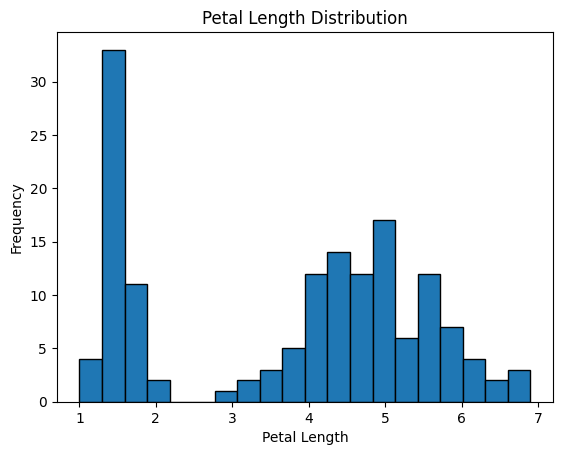

In [4]:
plt.hist(df["petal_length"], bins=20, edgecolor='black')
plt.title("Petal Length Distribution")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.show()

In [5]:
df = df.dropna()

In [6]:
df = df[df["species"] != "setosa"]

df["species"] = df["species"].map({
    "versicolor":0,
    "virginica":1
})

In [7]:
df = df.sample(100, random_state=42)

In [8]:
X = df[['petal_length','petal_width']]
y = df['species']

In [9]:
np.random.seed(42)

X = X + np.random.normal(0,0.3,X.shape)

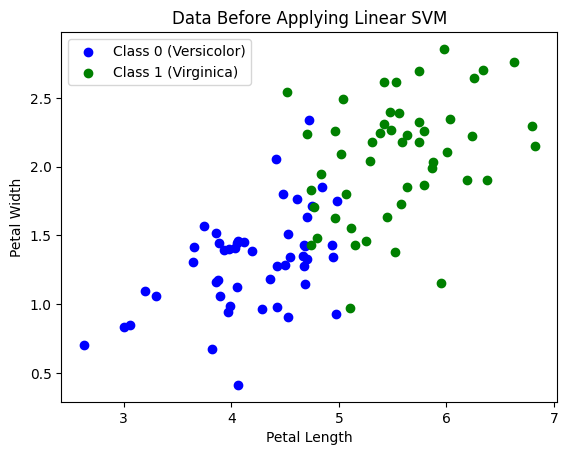

In [10]:
plt.scatter(X[y==0]['petal_length'],
            X[y==0]['petal_width'],
            color='blue',
            label='Class 0 (Versicolor)')

plt.scatter(X[y==1]['petal_length'],
            X[y==1]['petal_width'],
            color='green',
            label='Class 1 (Virginica)')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Data Before Applying Linear SVM")

plt.legend()

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.4,
random_state=42,
stratify=y
)

In [12]:
model = SVC(kernel='linear', C=0.5)

model.fit(X_train,y_train)

SVC(C=0.5, kernel='linear')

In [14]:
y_pred_train = model.predict(X_train)

y_pred_test = model.predict(X_test)

In [16]:
train_acc = accuracy_score(y_train,y_pred_train)
print("Training Accuracy:",train_acc)

Training Accuracy: 0.9


In [17]:
test_acc = accuracy_score(y_test,y_pred_test)
print("Testing Accuracy:",test_acc)

Testing Accuracy: 0.95


In [18]:
if train_acc - test_acc > 0.1:
    print("Model is Overfitting")
elif test_acc > train_acc:
    print("Model may be Underfitting")
else:
    print("Model is Well Fitted")

Model may be Underfitting


In [19]:
cm = confusion_matrix(y_test,y_pred_test)

print("Confusion Matrix:\n",cm)

Confusion Matrix:
 [[19  1]
 [ 1 19]]


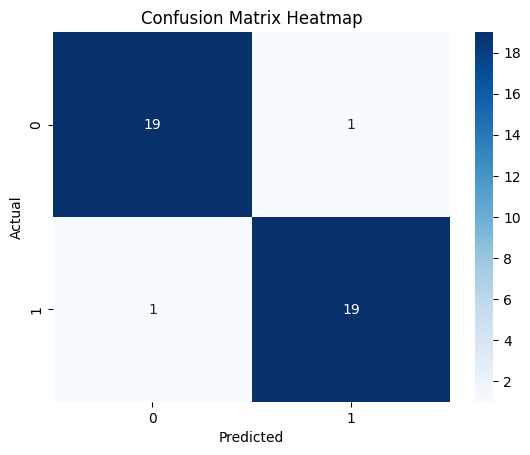

In [20]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
accuracy = accuracy_score(y_test,y_pred_test)
precision = precision_score(y_test,y_pred_test)
recall = recall_score(y_test,y_pred_test)
f1 = f1_score(y_test,y_pred_test)
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Accuracy: 0.95
Precision: 0.95
Recall: 0.95
F1 Score: 0.95


In [23]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



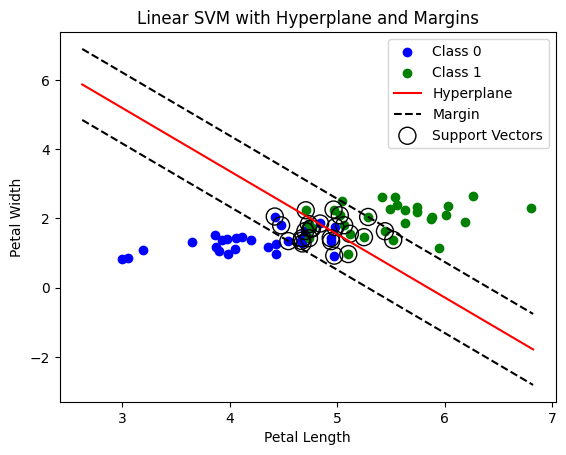

In [25]:
plt.scatter(X_train[y_train==0]['petal_length'],
            X_train[y_train==0]['petal_width'],
            color='blue',
            label='Class 0')

plt.scatter(X_train[y_train==1]['petal_length'],
            X_train[y_train==1]['petal_width'],
            color='green',
            label='Class 1')

# coefficients
w = model.coef_[0]
b = model.intercept_[0]

x_points = np.linspace(X['petal_length'].min(),
                       X['petal_length'].max())

# decision boundary (hyperplane)
y_points = -(w[0]/w[1])*x_points - b/w[1]

# margins
margin_up = -(w[0]/w[1])*x_points - (b-1)/w[1]
margin_down = -(w[0]/w[1])*x_points - (b+1)/w[1]

plt.plot(x_points,y_points,color='red',label='Hyperplane')
plt.plot(x_points,margin_up,'k--',label='Margin')
plt.plot(x_points,margin_down,'k--')

# support vectors
plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=150,
            facecolors='none',
            edgecolors='black',
            label='Support Vectors')

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Linear SVM with Hyperplane and Margins")
plt.legend()
plt.show()